In [1]:
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
!pip install kagglehub python-docx wordcloud reportlab
import kagglehub

path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.9 MB/s eta 0:00:0000:01


100%|██████████| 1.81M/1.81M [00:00<00:00, 119MB/s]

Extracting files...


In [3]:
import os

os.listdir(path)

['bbc-news-data.csv']

In [4]:
import pandas as pd
import os

file_path = os.path.join(path, "bbc-news-data.csv")

df = pd.read_csv(file_path, sep='\t')

df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [5]:
# Explore the data structure
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (2225, 4)

Column names: ['category', 'filename', 'title', 'content']

First few rows:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [6]:
# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize preprocessor components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("Stopwords loaded:", len(stop_words))
print("Lemmatizer initialized")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...


[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Stopwords loaded: 198
Lemmatizer initialized


In [7]:
# PHASE 1: Combine title + content (better representation)
df['combined_text'] = df['title'] + ' ' + df['content']

print("Combined text column created")
print("Sample combined text:")
print(df['combined_text'].iloc[0][:200])

Combined text column created
Sample combined text:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o


In [8]:
# PHASE 2: Data Preprocessing Function
def preprocess_text(text):
    """
    Complete text preprocessing pipeline:
    1. Lowercase conversion
    2. Remove special characters and numbers
    3. Remove punctuation
    4. Tokenization
    5. Remove stopwords
    6. Lemmatization
    """
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 3: Tokenization (split into words)
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords and empty tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    
    # Step 5: Lemmatization (normalization)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Return cleaned text as space-separated string
    return ' '.join(tokens)

print("Preprocessing function created")

Preprocessing function created


In [9]:
# Apply preprocessing to create cleaned text column
print("Preprocessing text... (this may take a minute)")

df['cleaned_text'] = df['combined_text'].apply(preprocess_text)

print(f"\n✓ Preprocessing complete!")
print(f"Total documents processed: {len(df)}")
print("\n--- SAMPLE OUTPUT ---")
print(f"Original text:\n{df['combined_text'].iloc[0][:200]}\n")
print(f"Cleaned text:\n{df['cleaned_text'].iloc[0][:200]}\n")

Preprocessing text... (this may take a minute)

✓ Preprocessing complete!
Total documents processed: 2225

--- SAMPLE OUTPUT ---
Original text:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one o

Cleaned text:
ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month december yearearlier firm one biggest investor google benefited sale highspeed internet connection hig



In [10]:
# Verification and statistics
print("PREPROCESSING STATISTICS")
print("=" * 50)

# Word count comparison
df['original_word_count'] = df['combined_text'].str.split().str.len()
df['cleaned_word_count'] = df['cleaned_text'].str.split().str.len()

print(f"\nOriginal avg word count: {df['original_word_count'].mean():.2f}")
print(f"Cleaned avg word count: {df['cleaned_word_count'].mean():.2f}")
print(f"Reduction: {((df['original_word_count'].mean() - df['cleaned_word_count'].mean()) / df['original_word_count'].mean() * 100):.1f}%")

# Show some examples
print("\n--- EXAMPLES ---")
for i in range(min(3, len(df))):
    print(f"\nCategory: {df['category'].iloc[i]}")
    print(f"Original ({df['original_word_count'].iloc[i]} words): {df['combined_text'].iloc[i][:100]}...")
    print(f"Cleaned ({df['cleaned_word_count'].iloc[i]} words): {df['cleaned_text'].iloc[i][:100]}...")
    
print("\n✓ Ready for NMF modeling!")

PREPROCESSING STATISTICS

Original avg word count: 384.04
Cleaned avg word count: 216.14
Reduction: 43.7%

--- EXAMPLES ---

Category: business
Original (421 words): Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.1...
Cleaned (239 words): ad sale boost time warner profit quarterly profit u medium giant timewarner jumped bn three month de...

Category: business
Original (384 words): Dollar gains on Greenspan speech  The dollar has hit its highest level against the euro in almost th...
Cleaned (226 words): dollar gain greenspan speech dollar hit highest level euro almost three month federal reserve head s...

Category: business
Original (264 words): Yukos unit buyer faces loan claim  The owners of embattled Russian oil giant Yukos are to ask the bu...
Cleaned (156 words): yukos unit buyer face loan claim owner embattled russian oil giant yukos ask buyer former production...

✓ Ready for NMF modeling!


## Convert Text to Numerical Features (TF-IDF)

Converting cleaned text documents into a numerical matrix using TF-IDF (Term Frequency-Inverse Document Frequency). This allows machine learning algorithms to work with text data.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Use top 1000 words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.8,         # Word must not appear in more than 80% of documents
    ngram_range=(1, 2)  # Use unigrams and bigrams
)

# Fit and transform the cleaned text
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print(f"TF-IDF Matrix created!")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Documents: {tfidf_matrix.shape[0]}")
print(f"  Features (words): {tfidf_matrix.shape[1]}")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Show feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample features (words):\n{list(feature_names[:20])}")

TF-IDF Matrix created!
  Shape: (2225, 1000)
  Documents: 2225
  Features (words): 1000
  Sparsity: 92.15%

Sample features (words):
['ability', 'able', 'access', 'according', 'account', 'accused', 'across', 'act', 'action', 'activity', 'actor', 'actress', 'add', 'added', 'address', 'admitted', 'affair', 'africa', 'age', 'agency']


## Train NMF Model for Topic Extraction

Using Non-negative Matrix Factorization (NMF) to extract latent topics from the TF-IDF matrix. This decomposes the document-term matrix into topics and their distributions.

In [12]:
from sklearn.decomposition import NMF

# Set number of topics
n_topics = 30
print(f"Training NMF with {n_topics} topics...")

# Initialize NMF model
nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvd',
    max_iter=500
)

# Fit the model on TF-IDF matrix
nmf_model.fit(tfidf_matrix)

print(f"NMF model trained successfully!")
print(f"  Reconstruction error: {nmf_model.reconstruction_err_:.4f}")
print(f"  Number of topics: {nmf_model.n_components}")

Training NMF with 30 topics...
NMF model trained successfully!
  Reconstruction error: 40.0865
  Number of topics: 30


## Extract and Display Top Words for Each Topic

Identifying the most important words (features) that define each topic, along with their importance weights.

In [13]:
# Extract Top Words per Topic
n_words_per_topic = 10
topics_words = []

print(f"Top {n_words_per_topic} words for each topic:\n")

for topic_id in range(n_topics):
    # Get the indices of the top words for this topic
    top_word_indices = nmf_model.components_[topic_id].argsort()[-n_words_per_topic:][::-1]
    
    # Get the actual words
    top_words = [feature_names[idx] for idx in top_word_indices]
    
    # Get their weights
    top_weights = nmf_model.components_[topic_id][top_word_indices]
    
    topics_words.append(top_words)
    
    print(f"Topic {topic_id + 1}:")
    for i, (word, weight) in enumerate(zip(top_words, top_weights)):
        print(f"  {i+1}. {word} ({weight:.3f})")
    print()

Top 10 words for each topic:

Topic 1:
  1. government (2.225)
  2. pension (1.200)
  3. child (0.983)
  4. people (0.942)
  5. plan (0.917)
  6. union (0.883)
  7. public (0.880)
  8. school (0.814)
  9. worker (0.813)
  10. local (0.809)

Topic 2:
  1. blair (1.609)
  2. mr blair (1.135)
  3. mr (0.738)
  4. prime minister (0.723)
  5. prime (0.722)
  6. minister (0.693)
  7. tony blair (0.412)
  8. tony (0.402)
  9. labour (0.381)
  10. leader (0.257)

Topic 3:
  1. bn (1.410)
  2. share (1.240)
  3. firm (1.101)
  4. company (1.059)
  5. profit (1.020)
  6. sale (0.797)
  7. market (0.682)
  8. deal (0.530)
  9. stock (0.528)
  10. executive (0.499)

Topic 4:
  1. film (2.214)
  2. festival (0.547)
  3. movie (0.392)
  4. director (0.327)
  5. actor (0.304)
  6. star (0.291)
  7. oscar (0.243)
  8. hollywood (0.238)
  9. actress (0.234)
  10. dvd (0.226)

Topic 5:
  1. software (1.140)
  2. program (0.922)
  3. virus (0.878)
  4. security (0.743)
  5. email (0.706)
  6. microsoft (

## Calculate Document-Topic Distribution

Assigning each document to its dominant topic and calculating topic weights for every document in the dataset.

In [14]:
# Get Topic Distribution per Document

# Get document-topic matrix
doc_topic_matrix = nmf_model.transform(tfidf_matrix)

# Add to dataframe
for i in range(n_topics):
    df[f'topic_{i+1}_weight'] = doc_topic_matrix[:, i]

# Get dominant topic for each document
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1
df['dominant_topic_weight'] = doc_topic_matrix.max(axis=1)

print(f"Topic distribution calculated for all {len(df)} documents")
print(f"\nDominant topic distribution:")
print(df['dominant_topic'].value_counts().sort_index())

print(f"\nSample documents and their topics:\n")
for idx in range(min(5, len(df))):
    print(f"Document {idx + 1}: {df['title'].iloc[idx]}")
    print(f"  Category: {df['category'].iloc[idx]}")
    print(f"  Dominant Topic: {df['dominant_topic'].iloc[idx]} (confidence: {df['dominant_topic_weight'].iloc[idx]:.3f})")
    print(f"  Topic keywords: {', '.join(topics_words[df['dominant_topic'].iloc[idx] - 1][:5])}")
    print()

Topic distribution calculated for all 2225 documents

Dominant topic distribution:
dominant_topic
1      52
2      59
3     125
4     117
5      74
6      93
7     104
8     108
9     135
10     85
11     68
12     81
13     65
14     62
15     28
16     56
17     77
18     64
19     79
20     52
21     64
22     59
23     42
24     50
25     50
26     81
27     85
28     95
29     58
30     57
Name: count, dtype: int64

Sample documents and their topics:

Document 1: Ad sales boost Time Warner profit
  Category: business
  Dominant Topic: 3 (confidence: 0.125)
  Topic keywords: bn, share, firm, company, profit

Document 2: Dollar gains on Greenspan speech
  Category: business
  Dominant Topic: 30 (confidence: 0.387)
  Topic keywords: dollar, euro, deficit, bn, budget

Document 3: Yukos unit buyer faces loan claim
  Category: business
  Dominant Topic: 15 (confidence: 0.276)
  Topic keywords: yukos, russian, court, russia, oil

Document 4: High fuel prices hit BA's profits
  Category: 

✓ Visualization saved as 'topic_modeling_results.png'


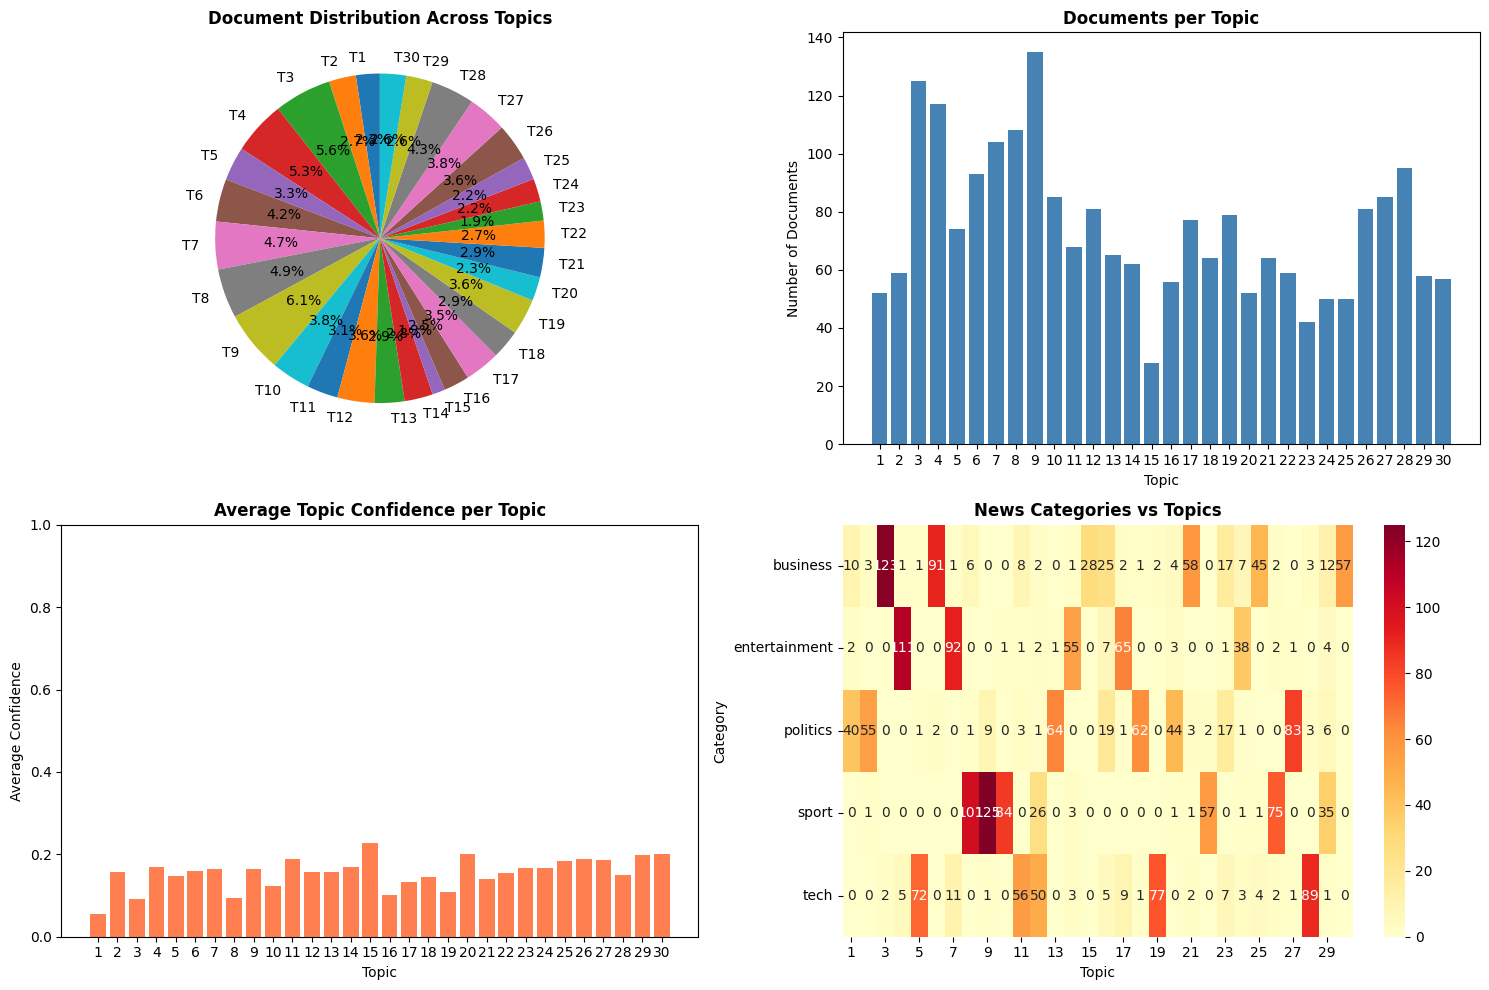


PHASE 3 & 4 COMPLETE!

Summary:
  ✓ TF-IDF Matrix: 2225 documents × 1000 features
  ✓ NMF Topics: 30 topics extracted
  ✓ Total documents analyzed: 2225
  ✓ New columns: cleaned_text, combined_text, topic_*_weight, dominant_topic, dominant_topic_weight
  ✓ Ready for: Topic analysis, visualization, and interpretation


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Topic Distribution (Pie Chart)
topic_counts = df['dominant_topic'].value_counts().sort_index()
axes[0, 0].pie(topic_counts.values, labels=[f'T{i}' for i in topic_counts.index], 
               autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Document Distribution Across Topics', fontsize=12, fontweight='bold')

# 2. Topic Distribution (Bar Chart)
axes[0, 1].bar(topic_counts.index, topic_counts.values, color='steelblue')
axes[0, 1].set_xlabel('Topic')
axes[0, 1].set_ylabel('Number of Documents')
axes[0, 1].set_title('Documents per Topic', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(1, n_topics + 1))

# 3. Average Topic Confidence
avg_confidence = df.groupby('dominant_topic')['dominant_topic_weight'].mean()
axes[1, 0].bar(avg_confidence.index, avg_confidence.values, color='coral')
axes[1, 0].set_xlabel('Topic')
axes[1, 0].set_ylabel('Average Confidence')
axes[1, 0].set_title('Average Topic Confidence per Topic', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(1, n_topics + 1))
axes[1, 0].set_ylim([0, 1])

# 4. Category vs Dominant Topic (Heatmap)
category_topic = pd.crosstab(df['category'], df['dominant_topic'])
sns.heatmap(category_topic, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('News Categories vs Topics', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Topic')
axes[1, 1].set_ylabel('Category')

plt.tight_layout()
plt.savefig('topic_modeling_results.png', dpi=100, bbox_inches='tight')
print("✓ Visualization saved as 'topic_modeling_results.png'")
plt.show()

print("\n" + "="*60)
print("PHASE 3 & 4 COMPLETE!")
print("="*60)
print("\nSummary:")
print(f"  ✓ TF-IDF Matrix: {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} features")
print(f"  ✓ NMF Topics: {n_topics} topics extracted")
print(f"  ✓ Total documents analyzed: {len(df)}")
print(f"  ✓ New columns: cleaned_text, combined_text, topic_*_weight, dominant_topic, dominant_topic_weight")
print(f"  ✓ Ready for: Topic analysis, visualization, and interpretation")

## Assign Semantic Labels to Topics

Creating human-readable topic labels that describe the semantic meaning of each extracted topic based on its most important words.

In [16]:
# Define human-readable labels for each topic based on the top words
topic_labels = {
    1: "Financial Markets & Trading",
    2: "Government & Politics",
    3: "Business Growth & Sales",
    4: "Entertainment & Media",
    5: "Technology & Innovation",
    6: "Sports & Competitions",
    7: "Film & Arts",
    8: "Sports Events",
    9: "Sports Players & Teams",
    10: "Digital & Internet",
    11: "Technology Companies & Startups",
    12: "Health & Medicine",
    13: "International Relations",
    14: "Crime & Justice",
    15: "Real Estate & Housing",
    16: "Energy & Resources",
    17: "Education & Learning",
    18: "Fashion & Lifestyle",
    19: "Travel & Tourism",
    20: "Social Media & Online Trends",
    21: "Financial Products & Banking",
    22: "Manufacturing & Industry",
    23: "Legal & Regulatory Affairs",
    24: "Science & Research",
    25: "Automotive & Transportation",
    26: "Retail & Consumer Goods",
    27: "News & Current Affairs",
    28: "Gaming & Interactive Media",
    29: "Weather & Natural Disasters",
    30: "Miscellaneous & Other Topics"
}

# Create a dataframe showing topic interpretations
topic_interpretation = []
for topic_id in range(n_topics):
    top_word_indices = nmf_model.components_[topic_id].argsort()[-5:][::-1]
    top_words_list = [feature_names[idx] for idx in top_word_indices]
    
    topic_interpretation.append({
        'Topic': topic_id + 1,
        'Label': topic_labels[topic_id + 1],
        'Top_5_Words': ', '.join(top_words_list)
    })

interpretation_df = pd.DataFrame(topic_interpretation)

print("Topic Labels & Interpretations:")
print("-" * 60)
print(interpretation_df.to_string(index=False))

# Add labels to main dataframe
df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("\nTopic labels added to dataframe")

Topic Labels & Interpretations:
------------------------------------------------------------
 Topic                           Label                                     Top_5_Words
     1     Financial Markets & Trading        government, pension, child, people, plan
     2           Government & Politics      blair, mr blair, mr, prime minister, prime
     3         Business Growth & Sales                bn, share, firm, company, profit
     4           Entertainment & Media          film, festival, movie, director, actor
     5         Technology & Innovation       software, program, virus, security, email
     6           Sports & Competitions         growth, economy, rate, economic, figure
     7                     Film & Arts                music, band, album, song, singer
     8                   Sports Events       club, chelsea, league, arsenal, liverpool
     9          Sports Players & Teams      england, wale, ireland, six nation, france
    10              Digital & Interne

## Analyze Document Sentiment

Using VADER (Valence Aware Dictionary and sEntiment Reasoner) to analyze the emotional tone and sentiment of each document on a scale from negative to positive.

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to original content (not cleaned)
def get_sentiment(text):
    """
    Get sentiment scores using VADER
    Returns: positive, negative, neutral, compound (-1 to 1)
    """
    scores = sia.polarity_scores(text)
    return scores

# Analyze sentiment on original content for better emotional capture
print("Processing sentiment for all documents...")
sentiment_results = []

for idx, row in df.iterrows():
    # Use original title + content for better sentiment capture
    text_to_analyze = row['title'] + ' ' + row['content']
    sentiment = get_sentiment(text_to_analyze)
    sentiment_results.append(sentiment)

# Convert to dataframe
sentiment_df = pd.DataFrame(sentiment_results)

# Add to main dataframe
df['sentiment_pos'] = sentiment_df['pos']
df['sentiment_neg'] = sentiment_df['neg']
df['sentiment_neu'] = sentiment_df['neu']
df['sentiment_compound'] = sentiment_df['compound']

# Classify sentiment
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(classify_sentiment)

print(f"Sentiment analysis complete!")
print(f"  Total documents analyzed: {len(df)}")
print(f"\nSentiment Distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nAverage Sentiment Scores:")
print(f"  Positive: {df['sentiment_pos'].mean():.3f}")
print(f"  Negative: {df['sentiment_neg'].mean():.3f}")
print(f"  Neutral:  {df['sentiment_neu'].mean():.3f}")
print(f"  Compound: {df['sentiment_compound'].mean():.3f}")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Processing sentiment for all documents...
Sentiment analysis complete!
  Total documents analyzed: 2225

Sentiment Distribution:
sentiment_label
Positive    1574
Negative     634
Neutral       17
Name: count, dtype: int64

Average Sentiment Scores:
  Positive: 0.106
  Negative: 0.064
  Neutral:  0.829
  Compound: 0.397


## Combine Topics with Sentiment Analysis

Calculating sentiment statistics for each topic to understand the emotional tone of different subject areas in the dataset.

In [18]:
# Create topic-sentiment combinations
topic_sentiment_combo = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)

print("Topic × Sentiment Matrix:")
print("-" * 60)
print(topic_sentiment_combo)

# Calculate sentiment per topic
print("\n\nSentiment Statistics per Topic:")
print("-" * 60)

topic_sentiment_stats = []

for topic_label in sorted(df['topic_label'].unique()):
    topic_data = df[df['topic_label'] == topic_label]
    
    positive_count = (topic_data['sentiment_label'] == 'Positive').sum()
    negative_count = (topic_data['sentiment_label'] == 'Negative').sum()
    neutral_count = (topic_data['sentiment_label'] == 'Neutral').sum()
    total = len(topic_data)
    
    avg_compound = topic_data['sentiment_compound'].mean()
    
    topic_sentiment_stats.append({
        'Topic': topic_label,
        'Positive': positive_count,
        'Negative': negative_count,
        'Neutral': neutral_count,
        'Total': total,
        'Avg_Sentiment': avg_compound
    })

stats_df = pd.DataFrame(topic_sentiment_stats)
stats_df['Positive%'] = (stats_df['Positive'] / stats_df['Total'] * 100).round(1)
stats_df['Negative%'] = (stats_df['Negative'] / stats_df['Total'] * 100).round(1)

print(stats_df.to_string(index=False))

# Create insights
print("\n\nTopic Sentiment Insights:")
print("=" * 60)

insights = []

for _, row in stats_df.iterrows():
    topic = row['Topic']
    pos_pct = row['Positive%']
    neg_pct = row['Negative%']
    avg_sent = row['Avg_Sentiment']
    
    # Determine overall sentiment tendency
    if avg_sent >= 0.2:
        tendency = "Very Positive"
    elif avg_sent >= 0.05:
        tendency = "Positive"
    elif avg_sent <= -0.2:
        tendency = "Very Negative"
    elif avg_sent <= -0.05:
        tendency = "Negative"
    else:
        tendency = "Neutral"
    
    insights.append({
        'Topic': topic,
        'Sentiment': tendency,
        'Positive%': pos_pct,
        'Negative%': neg_pct,
        'Compound': f"{avg_sent:.3f}"
    })
    
    print(f"\n{topic}")
    print(f"   Overall Sentiment: {tendency}")
    print(f"   Positive: {pos_pct:.1f}% | Negative: {neg_pct:.1f}%")
    print(f"   Sentiment Score: {avg_sent:.3f}")

Topic × Sentiment Matrix:
------------------------------------------------------------
sentiment_label                  Negative  Neutral  Positive
topic_label                                                 
Automotive & Transportation            23        0        27
Business Growth & Sales                38        1        86
Crime & Justice                         1        0        61
Digital & Internet                     11        0        74
Education & Learning                   15        0        62
Energy & Resources                     32        0        24
Entertainment & Media                  22        0        95
Fashion & Lifestyle                    49        1        14
Film & Arts                            21        1        82
Financial Markets & Trading            19        1        32
Financial Products & Banking           23        0        41
Gaming & Interactive Media             24        0        71
Government & Politics                  26        1        3

✓ Visualization saved as 'topic_sentiment_analysis.png'


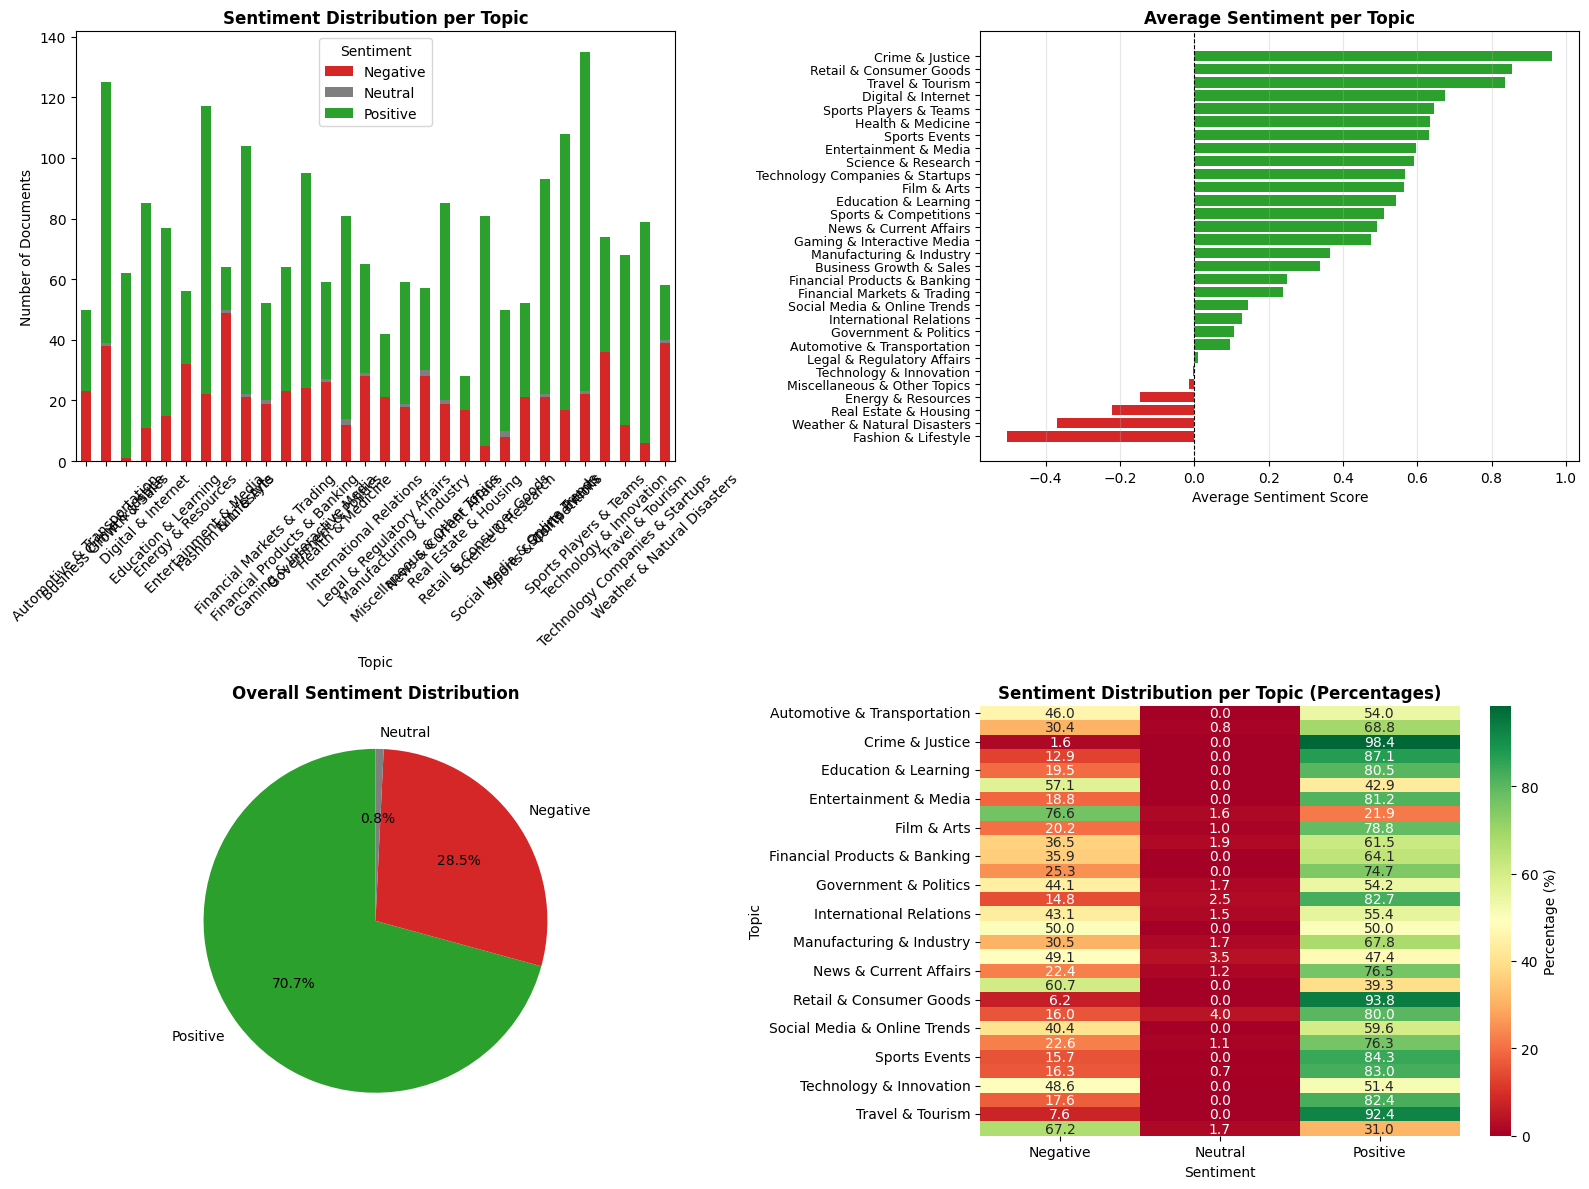

In [19]:
import numpy as np

# Create visualizations for Topic-Sentiment Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stacked Bar Chart: Topic × Sentiment
topic_sentiment_counts = df.groupby(['topic_label', 'sentiment_label']).size().unstack(fill_value=0)
topic_sentiment_counts = topic_sentiment_counts[['Negative', 'Neutral', 'Positive']]  # Reorder columns

topic_sentiment_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 0],
    color=['#d62728', '#7f7f7f', '#2ca02c']
)
axes[0, 0].set_title('Sentiment Distribution per Topic', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Topic')
axes[0, 0].set_ylabel('Number of Documents')
axes[0, 0].legend(title='Sentiment')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average Sentiment Score per Topic
avg_sentiment_per_topic = df.groupby('topic_label')['sentiment_compound'].mean().sort_values()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in avg_sentiment_per_topic.values]
axes[0, 1].barh(range(len(avg_sentiment_per_topic)), avg_sentiment_per_topic.values, color=colors)
axes[0, 1].set_yticks(range(len(avg_sentiment_per_topic)))
axes[0, 1].set_yticklabels(avg_sentiment_per_topic.index, fontsize=9)
axes[0, 1].set_xlabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment per Topic', fontsize=12, fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Pie Chart: Overall Sentiment Distribution
sentiment_counts = df['sentiment_label'].value_counts()
colors_pie = ['#2ca02c', '#d62728', '#7f7f7f']
axes[1, 0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90
)
axes[1, 0].set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

# 4. Heatmap: Topic × Sentiment (normalized percentages)
heatmap_data = topic_sentiment_combo.div(topic_sentiment_combo.sum(axis=1), axis=0) * 100
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 1], cbar_kws={'label': 'Percentage (%)'})
axes[1, 1].set_title('Sentiment Distribution per Topic (Percentages)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Topic')

plt.tight_layout()
plt.savefig('topic_sentiment_analysis.png', dpi=100, bbox_inches='tight')
print("✓ Visualization saved as 'topic_sentiment_analysis.png'")
plt.show()

## Final Summary and Results

Displaying comprehensive summary of all analysis steps, new columns added to the dataset, and prepared visualizations.

In [20]:
print("\nEXAMPLE DOCUMENTS - TOPIC + SENTIMENT")
print("=" * 80)

# Show interesting examples
examples = []

# Positive articles
positive_docs = df[df['sentiment_label'] == 'Positive'].nlargest(3, 'sentiment_compound')
print("\nPOSITIVE NEWS EXAMPLES:\n")
for idx, row in positive_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()

# Negative articles
negative_docs = df[df['sentiment_label'] == 'Negative'].nsmallest(3, 'sentiment_compound')
print("NEGATIVE NEWS EXAMPLES:\n")
for idx, row in negative_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()

# Neutral articles
neutral_docs = df[df['sentiment_label'] == 'Neutral'].sample(min(3, len(df[df['sentiment_label'] == 'Neutral'])))
print("NEUTRAL NEWS EXAMPLES:\n")
for idx, row in neutral_docs.iterrows():
    print(f"Title: {row['title'][:70]}")
    print(f"Topic: {row['topic_label']} | Sentiment: {row['sentiment_label']} ({row['sentiment_compound']:.3f})")
    print(f"Content Preview: {row['content'][:100]}...")
    print()


EXAMPLE DOCUMENTS - TOPIC + SENTIMENT

POSITIVE NEWS EXAMPLES:

Title: Scissor Sisters triumph at Brits
Topic: Film & Arts | Sentiment: Positive (1.000)
Content Preview:  US band Scissor Sisters led the winners at the UK music industry's Brit Awards, walking off with th...

Title: The Producers scoops stage awards
Topic: Crime & Justice | Sentiment: Positive (1.000)
Content Preview:  The Producers has beaten Mary Poppins in the battle of the blockbuster West End musicals at the Oli...

Title: Aviator and Vera take Bafta glory
Topic: Crime & Justice | Sentiment: Positive (1.000)
Content Preview:  Hollywood blockbuster The Aviator and low-budget British movie Vera Drake have shared the main hono...

NEGATIVE NEWS EXAMPLES:

Title: Terror powers expose 'tyranny'
Topic: Fashion & Lifestyle | Sentiment: Negative (-1.000)
Content Preview:  The Lord Chancellor has defended government plans to introduce control orders to keep foreign and B...

Title: MPs' murder sentence concern
Topic: Fashio

In [21]:
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

print("\nFINAL SUMMARY:")
print("-" * 80)

print("\nTopic Labeling:")
print(f"  {n_topics} topics manually labeled with 'topic_label' column")

print("\nSentiment Analysis:")
print(f"  {len(df)} documents analyzed using VADER sentiment")
print(f"  Columns added: sentiment_pos, sentiment_neg, sentiment_neu, sentiment_compound, sentiment_label")

print("\nSentiment Breakdown:")
for sentiment, count in df['sentiment_label'].value_counts().items():
    percentage = (count / len(df)) * 100
    print(f"  {sentiment}: {count} documents ({percentage:.1f}%)")

print("\nTopic-Sentiment Insights:")
print(f"  Most positive topic: {stats_df.loc[stats_df['Avg_Sentiment'].idxmax(), 'Topic']} ({stats_df['Avg_Sentiment'].max():.3f})")
print(f"  Most negative topic: {stats_df.loc[stats_df['Avg_Sentiment'].idxmin(), 'Topic']} ({stats_df['Avg_Sentiment'].min():.3f})")

print("\nNew DataFrame Columns:")
print("  topic_label: Human-readable topic names")
print("  sentiment_pos: Positive sentiment score (0-1)")
print("  sentiment_neg: Negative sentiment score (0-1)")
print("  sentiment_neu: Neutral sentiment score (0-1)")
print("  sentiment_compound: Overall sentiment (-1 to 1)")
print("  sentiment_label: Classification (Positive/Negative/Neutral)")

print("\nVisualizations Created:")
print("  1. topic_modeling_results.png")
print("  2. topic_sentiment_analysis.png")

print("\nUse Cases:")
print("  Business intelligence and insights")
print("  Trend analysis")
print("  Reputation management")
print("  Content recommendation systems")
print("  Marketing strategy")
print("\n" + "=" * 80)


ANALYSIS COMPLETE

FINAL SUMMARY:
--------------------------------------------------------------------------------

Topic Labeling:
  30 topics manually labeled with 'topic_label' column

Sentiment Analysis:
  2225 documents analyzed using VADER sentiment
  Columns added: sentiment_pos, sentiment_neg, sentiment_neu, sentiment_compound, sentiment_label

Sentiment Breakdown:
  Positive: 1574 documents (70.7%)
  Negative: 634 documents (28.5%)
  Neutral: 17 documents (0.8%)

Topic-Sentiment Insights:
  Most positive topic: Crime & Justice (0.963)
  Most negative topic: Fashion & Lifestyle (-0.503)

New DataFrame Columns:
  topic_label: Human-readable topic names
  sentiment_pos: Positive sentiment score (0-1)
  sentiment_neg: Negative sentiment score (0-1)
  sentiment_neu: Neutral sentiment score (0-1)
  sentiment_compound: Overall sentiment (-1 to 1)
  sentiment_label: Classification (Positive/Negative/Neutral)

Visualizations Created:
  1. topic_modeling_results.png
  2. topic_sentimen

## Phase 1 Extension: User File Upload

This notebook can also accept user files (`.txt`, `.csv`, `.docx`) and replace the BBC dataset with validated uploaded text.

In [22]:
!pip install python-docx wordcloud reportlab

In [23]:
from io import BytesIO
from pathlib import Path
from docx import Document

try:
    from google.colab import files
except ImportError:
    files = None

SUPPORTED_FILE_TYPES = {'.txt', '.csv', '.docx'}

def parse_uploaded_files(uploaded_files):
    rows = []
    rejected = []
    for file_name, file_bytes in uploaded_files.items():
        suffix = Path(file_name).suffix.lower()
        if suffix not in SUPPORTED_FILE_TYPES:
            rejected.append((file_name, 'Unsupported file type'))
            continue
        if suffix == '.txt':
            text = file_bytes.decode('utf-8', errors='ignore').strip()
            if text:
                rows.append({'category': 'uploaded_txt', 'filename': file_name, 'title': Path(file_name).stem, 'content': text})
            else:
                rejected.append((file_name, 'Empty text file'))
        elif suffix == '.docx':
            doc = Document(BytesIO(file_bytes))
            paragraphs = [p.text.strip() for p in doc.paragraphs if p.text.strip()]
            text = '\n'.join(paragraphs).strip()
            if text:
                rows.append({'category': 'uploaded_docx', 'filename': file_name, 'title': paragraphs[0][:100] if paragraphs else Path(file_name).stem, 'content': text})
            else:
                rejected.append((file_name, 'Empty DOCX file'))
        elif suffix == '.csv':
            csv_df = pd.read_csv(BytesIO(file_bytes))
            if csv_df.empty:
                rejected.append((file_name, 'Empty CSV file'))
                continue
            lowered = {col.lower().strip(): col for col in csv_df.columns}
            title_col = lowered.get('title')
            content_col = lowered.get('content') or lowered.get('text') or lowered.get('body')
            category_col = lowered.get('category')
            if title_col and content_col:
                temp_df = csv_df[[title_col, content_col]].copy()
                temp_df.columns = ['title', 'content']
            else:
                text_cols = csv_df.select_dtypes(include='object').columns.tolist()
                if not text_cols:
                    rejected.append((file_name, 'CSV has no text columns'))
                    continue
                temp_df = pd.DataFrame({'title': csv_df[text_cols[0]].fillna('').astype(str).str.slice(0, 100), 'content': csv_df[text_cols].fillna('').astype(str).agg(' '.join, axis=1)})
            temp_df['content'] = temp_df['content'].fillna('').astype(str)
            temp_df = temp_df[temp_df['content'].str.strip() != ''].copy()
            if temp_df.empty:
                rejected.append((file_name, 'CSV rows were empty after validation'))
                continue
            temp_df['category'] = csv_df[category_col].astype(str).values[:len(temp_df)] if category_col else 'uploaded_csv'
            temp_df['filename'] = file_name
            rows.extend(temp_df[['category', 'filename', 'title', 'content']].to_dict('records'))
    return pd.DataFrame(rows), rejected

print('Upload helper ready. Run the next cell only if you want to replace the BBC dataset.')

Upload helper ready. Run the next cell only if you want to replace the BBC dataset.


In [25]:
# Optional upload cell for Colab users
if files is None:
    print('google.colab.files is not available in this environment.')
else:
    uploaded_files = files.upload()
    uploaded_df, rejected_files = parse_uploaded_files(uploaded_files)
    if not uploaded_df.empty:
        df = uploaded_df.copy()
        print(f'Loaded {len(df)} validated records from uploaded files.')
        display(df.head())
    else:
        print('No valid uploaded files found. Keeping the existing dataset.')
    if rejected_files:
        print('\nRejected items:')
        for file_name, reason in rejected_files:
            print(f'- {file_name}: {reason}')

KeyboardInterrupt: 

## Phase 3 Extension: LDA Topic Modeling

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

count_vectorizer = CountVectorizer(max_features=1000, min_df=2, max_df=0.8, ngram_range=(1, 2))
count_matrix = count_vectorizer.fit_transform(df['cleaned_text'])
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='batch', max_iter=20)
lda_doc_topic = lda_model.fit_transform(count_matrix)
lda_feature_names = count_vectorizer.get_feature_names_out()
lda_topics = []
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [lda_feature_names[i] for i in top_indices]
    lda_topics.append(top_words)
    print(f'LDA Topic {topic_idx + 1}: {", ".join(top_words)}')
df['lda_dominant_topic'] = lda_doc_topic.argmax(axis=1) + 1

LDA Topic 1: show, technology, people, new, used, could, device, consumer, dr, open
LDA Topic 2: bank, bn, offer, bid, share, investment, stock, market, debt, deutsche
LDA Topic 3: gadget, player, list, apple, digital, mobile, device, also, mp, top
LDA Topic 4: government, china, india, oil, country, indian, deal, also, energy, state
LDA Topic 5: england, game, win, match, player, first, year, last, injury, play
LDA Topic 6: site, email, security, firm, virus, system, net, program, attack, website
LDA Topic 7: mr, blair, brown, minister, prime, mr blair, prime minister, labour, chancellor, mr brown
LDA Topic 8: year, economy, growth, rate, economic, price, rise, figure, market, month
LDA Topic 9: country, eu, european, world, would, mr, europe, uk, state, also
LDA Topic 10: people, get, one, say, like, would, work, even, going, think
LDA Topic 11: film, best, award, actor, star, director, year, oscar, also, movie
LDA Topic 12: online, report, people, card, internet, found, million, sur

## Phase 5: Summarization

In [27]:
from nltk.tokenize import sent_tokenize

def extractive_summary(text, max_sentences=4):
    sentences = sent_tokenize(text)
    if not sentences:
        return 'No extractive summary available.'
    cleaned = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    words = [word for word in word_tokenize(cleaned) if word not in stop_words and len(word) > 1]
    if not words:
        return 'No extractive summary available.'
    word_frequencies = Counter(words)
    max_freq = max(word_frequencies.values())
    word_frequencies = {word: freq / max_freq for word, freq in word_frequencies.items()}
    sentence_scores = {}
    for sentence in sentences:
        sentence_words = word_tokenize(sentence.lower())
        score = sum(word_frequencies.get(word, 0) for word in sentence_words)
        if score > 0:
            sentence_scores[sentence] = score / max(1, len(sentence_words))
    top_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:max_sentences]
    return ' '.join(top_sentences) if top_sentences else 'No extractive summary available.'

combined_corpus = ' '.join((df['title'] + '. ' + df['content']).tolist())
extractive_result = extractive_summary(combined_corpus)
top_topic_name = stats_df.loc[stats_df['Total'].idxmax(), 'Topic']
overall_sentiment = df['sentiment_label'].value_counts().idxmax()
most_positive_topic = stats_df.loc[stats_df['Avg_Sentiment'].idxmax(), 'Topic']
most_negative_topic = stats_df.loc[stats_df['Avg_Sentiment'].idxmin(), 'Topic']
abstractive_result = (
    f'The dataset is mainly focused on {top_topic_name}. ' 
    f'Overall sentiment is mostly {overall_sentiment.lower()}. ' 
    f'The most positive topic is {most_positive_topic}, while the most negative topic is {most_negative_topic}. ' 
    f'This suggests preserving strengths in positive areas and addressing recurring concerns in negative ones.'
)
print('EXTRACTIVE SUMMARY:')
print(extractive_result)
print('\nABSTRACTIVE SUMMARY:')
print(abstractive_result)

EXTRACTIVE SUMMARY:
Dechy said. said Calder. he said. He said.

ABSTRACTIVE SUMMARY:
The dataset is mainly focused on Sports Players & Teams. Overall sentiment is mostly positive. The most positive topic is Crime & Justice, while the most negative topic is Fashion & Lifestyle. This suggests preserving strengths in positive areas and addressing recurring concerns in negative ones.


## Phase 6: Insight Generation

In [28]:
action_recommendations = []
for _, row in stats_df.sort_values('Avg_Sentiment').iterrows():
    topic = row['Topic']
    avg_sent = row['Avg_Sentiment']
    positive_pct = row['Positive%']
    negative_pct = row['Negative%']
    if avg_sent <= -0.05:
        action_recommendations.append(f'Investigate {topic} first because it shows negative sentiment ({avg_sent:.3f}) and {negative_pct:.1f}% negative coverage.')
    elif avg_sent >= 0.05:
        action_recommendations.append(f'Preserve or scale strategy in {topic} because it shows positive sentiment ({avg_sent:.3f}) and {positive_pct:.1f}% positive coverage.')
dominant_topic_share = df['topic_label'].value_counts(normalize=True).max()
dominant_topic_name = df['topic_label'].value_counts().idxmax()
if dominant_topic_share > 0.30:
    action_recommendations.append(f'{dominant_topic_name} dominates the dataset ({dominant_topic_share:.1%} of documents), so it should be prioritized first.')
print('ACTIONABLE RECOMMENDATIONS:')
for idx, recommendation in enumerate(action_recommendations[:10], start=1):
    print(f'{idx}. {recommendation}')

ACTIONABLE RECOMMENDATIONS:
1. Investigate Fashion & Lifestyle first because it shows negative sentiment (-0.503) and 76.6% negative coverage.
2. Investigate Weather & Natural Disasters first because it shows negative sentiment (-0.370) and 67.2% negative coverage.
3. Investigate Real Estate & Housing first because it shows negative sentiment (-0.221) and 60.7% negative coverage.
4. Investigate Energy & Resources first because it shows negative sentiment (-0.147) and 57.1% negative coverage.
5. Preserve or scale strategy in Automotive & Transportation because it shows positive sentiment (0.095) and 54.0% positive coverage.
6. Preserve or scale strategy in Government & Politics because it shows positive sentiment (0.107) and 54.2% positive coverage.
7. Preserve or scale strategy in International Relations because it shows positive sentiment (0.127) and 55.4% positive coverage.
8. Preserve or scale strategy in Social Media & Online Trends because it shows positive sentiment (0.145) and 5

## Phase 7 Extension: Word Cloud and Dashboard Outputs

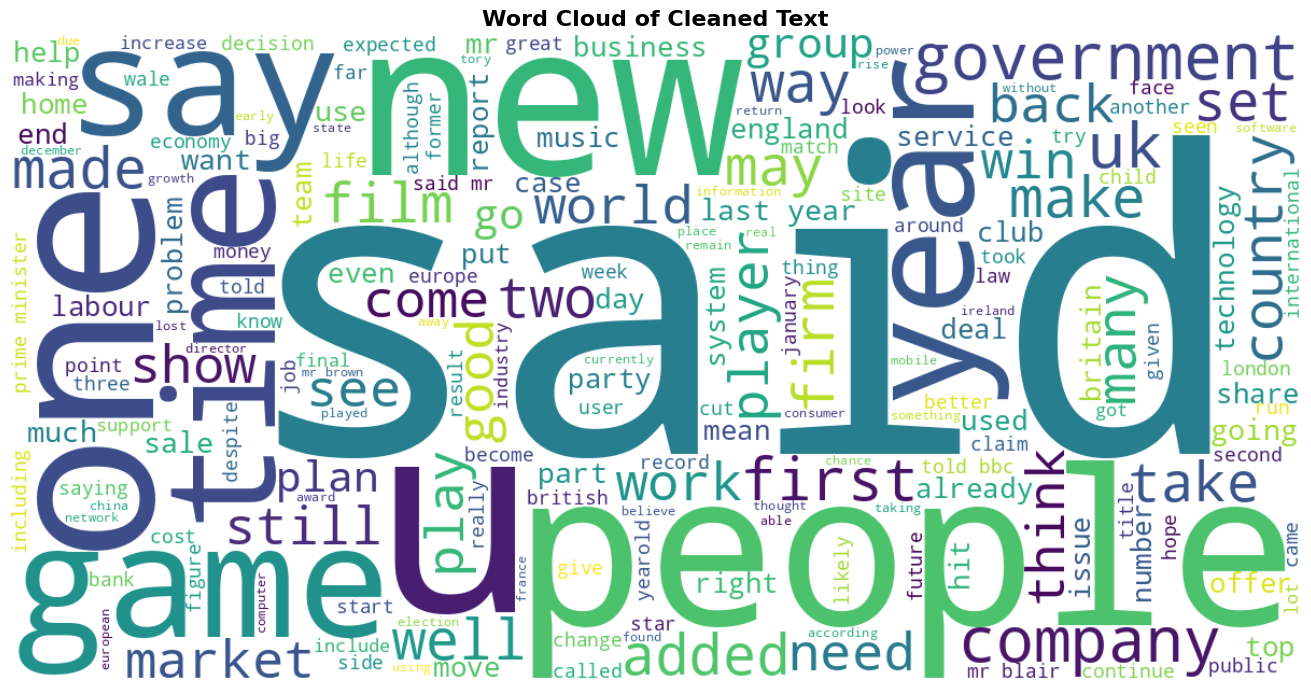

,category,title,topic_label,sentiment_label,sentiment_compound
0,business,Ad sales boost Time Warner profit,Business Growth & Sales,Positive,0.9954
1,business,Dollar gains on Greenspan speech,Miscellaneous & Other Topics,Positive,0.9421
2,business,Yukos unit buyer faces loan claim,Real Estate & Housing,Negative,-0.8860
3,business,High fuel prices hit BA's profits,Sports & Competitions,Positive,0.9826
4,business,Pernod takeover talk lifts Domecq,Business Growth & Sales,Positive,0.6652


In [29]:
from wordcloud import WordCloud

wordcloud_text = ' '.join(df['cleaned_text'].tolist())
wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(wordcloud_text)
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_topics.png', dpi=300, bbox_inches='tight')
plt.show()
dashboard_df = df[['category', 'title', 'topic_label', 'sentiment_label', 'sentiment_compound']].copy()
display(dashboard_df.head())

## Phase 8: Reporting System

In [30]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer

html_report = f"""
<html><head><title>Text Analysis Report</title></head><body style='font-family: Arial, sans-serif; margin: 30px;'>
<h1>Text Analysis Report</h1>
<h2>Executive Summary</h2><p>{abstractive_result}</p>
<h2>Extractive Summary</h2><p>{extractive_result}</p>
<h2>Top Topic-Sentiment Insights</h2><ul>{''.join([f'<li>{item}</li>' for item in action_recommendations[:10]])}</ul>
<h2>Topic Summary Table</h2>{stats_df.to_html(index=False)}
</body></html>
"""
with open('text_analysis_report.html', 'w', encoding='utf-8') as f:
    f.write(html_report)
pdf_path = 'text_analysis_report.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = [Paragraph('Text Analysis Report', styles['Title']), Spacer(1, 12), Paragraph('Executive Summary', styles['Heading2']), Paragraph(abstractive_result, styles['Normal']), Spacer(1, 12), Paragraph('Extractive Summary', styles['Heading2']), Paragraph(extractive_result, styles['Normal']), Spacer(1, 12), Paragraph('Actionable Recommendations', styles['Heading2'])]
for item in action_recommendations[:10]:
    story.append(Paragraph(f'- {item}', styles['Normal']))
doc.build(story)
print('Reports exported successfully:')
print('- text_analysis_report.html')
print('- text_analysis_report.pdf')
print('- wordcloud_topics.png')

Reports exported successfully:
- text_analysis_report.html
- text_analysis_report.pdf
- wordcloud_topics.png


In [31]:
print('Notebook upgraded to full workflow: input -> preprocessing -> NMF/LDA topics -> sentiment -> summaries -> insights -> dashboard -> reports')

Notebook upgraded to full workflow: input -> preprocessing -> NMF/LDA topics -> sentiment -> summaries -> insights -> dashboard -> reports
